# Load Data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Data Analytics/Git_Clone_PakHandaru/datasets/pima_indians_diabetes.csv')

In [2]:
# Nama kolom
df.columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
5,3,78,50,32,88,31.0,0.248,26,1
6,10,115,0,0,0,35.3,0.134,29,0
7,2,197,70,45,543,30.5,0.158,53,1
8,8,125,96,0,0,0.0,0.232,54,1
9,4,110,92,0,0,37.6,0.191,30,0


##### Uji Anova (Untuk Feature Selection)

In [51]:
from scipy.stats import ttest_ind

# Loop semua kolom numerik vs Outcome
for col in df.columns[:-1]:  # loop kecuali kolom 'Outcome'
    group0 = df[df['Outcome'] == 0][col]
    group1 = df[df['Outcome'] == 1][col]

    stat, p = ttest_ind(group0, group1, equal_var=False)  # Gunakan Welch’s t-test
    print(f"{col:<25} → p-value = {p:.4f}")

Pregnancies               → p-value = 0.0000
Glucose                   → p-value = 0.0000
BloodPressure             → p-value = 0.0887
SkinThickness             → p-value = 0.0544
Insulin                   → p-value = 0.0009
BMI                       → p-value = 0.0000
DiabetesPedigreeFunction  → p-value = 0.0000
Age                       → p-value = 0.0000


| Fitur                        | P-Value | Signifikan? | Penjelasan                                                          |
| ---------------------------- | ------- | ----------- | ------------------------------------------------------------------- |
| **Pregnancies**              | 0.0000  | ✅ Ya        | Jumlah kehamilan beda signifikan antara yang diabetes dan tidak.    |
| **Glucose**                  | 0.0000  | ✅ Ya        | Glukosa sangat berpengaruh terhadap outcome diabetes.               |
| **BloodPressure**            | 0.0887  | ❌ Tidak     | Tidak beda signifikan antar kelompok (p > 0.05).                    |
| **SkinThickness**            | 0.0544  | ❌ Tidak     | Tidak beda signifikan antar kelompok (p > 0.05).                    |
| **Insulin**                  | 0.0002  | ✅ Ya        | Sangat signifikan.                                                  |
| **BMI**                      | 0.0000  | ✅ Ya        | Sangat signifikan — obesitas terkait kuat dengan diabetes.          |
| **DiabetesPedigreeFunction** | 0.0000  | ✅ Ya        | Faktor genetik signifikan terhadap outcome.                         |
| **Age**                      | 0.0000  | ✅ Ya        | Usia lebih tua punya kemungkinan diabetes lebih tinggi.             |


In [52]:
selected_features = [
    "Pregnancies",
    "Glucose",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

# X hanya berisi kolom yang dipilih
X = df[selected_features].values
y = df["Outcome"].values


#### Feature Selection Menggunakan Random Forest

📊 Feature Importance (sorted):
Glucose                   → Importance: 0.3022
BMI                       → Importance: 0.2029
Age                       → Importance: 0.1560
DiabetesPedigreeFunction  → Importance: 0.1524
Pregnancies               → Importance: 0.0985
Insulin                   → Importance: 0.0881


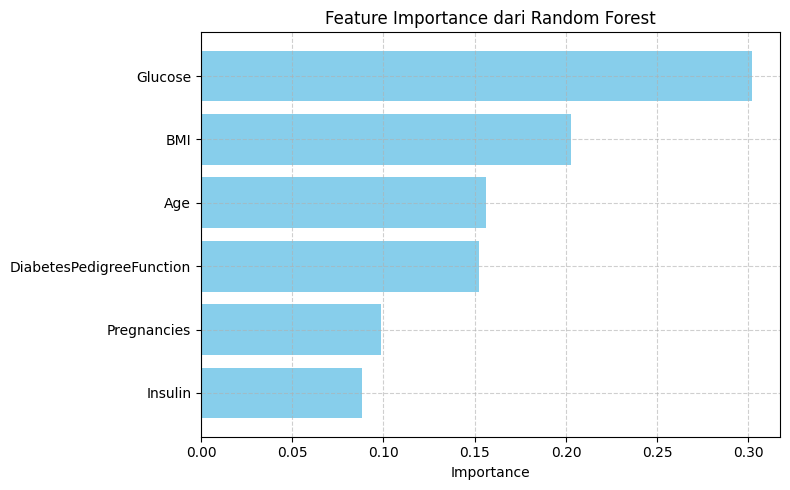

In [53]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

model = RandomForestClassifier()
model.fit(X, y)

# Ambil feature importance dan sort
importances = model.feature_importances_
features = np.array(selected_features)
sorted_idx = np.argsort(importances)[::-1]

# Tampilkan hasil
print("📊 Feature Importance (sorted):")
for i in sorted_idx:
    print(f"{features[i]:<25} → Importance: {importances[i]:.4f}")

# Visualisasi bar chart
plt.figure(figsize=(8,5))
plt.barh(features[sorted_idx], importances[sorted_idx], color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance dari Random Forest")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
selected_features = [ # 4 Feature dengan nilai importance tertinggi
    "Glucose",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

# X hanya berisi kolom yang dipilih
X = df[selected_features].values
y = df["Outcome"].values

# Normalisasi
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Split manual
def train_test_split(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    test_count = int(test_size * X.shape[0])
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Linear Regression

Linear regresi memiliki syarat linearity, independence, dan normality

#### Cek hubungan linear 

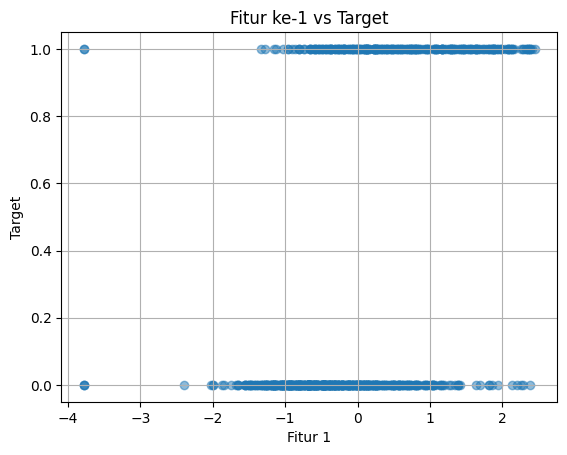

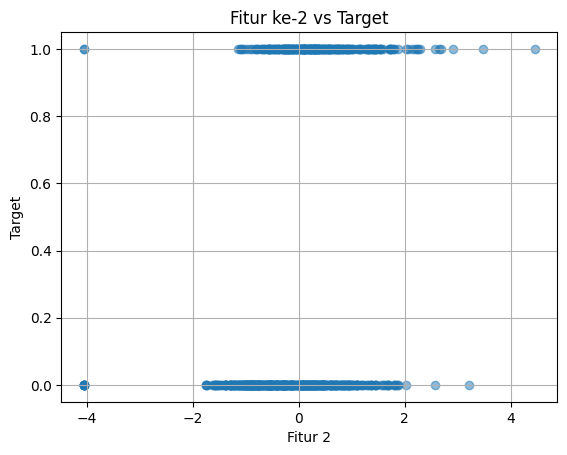

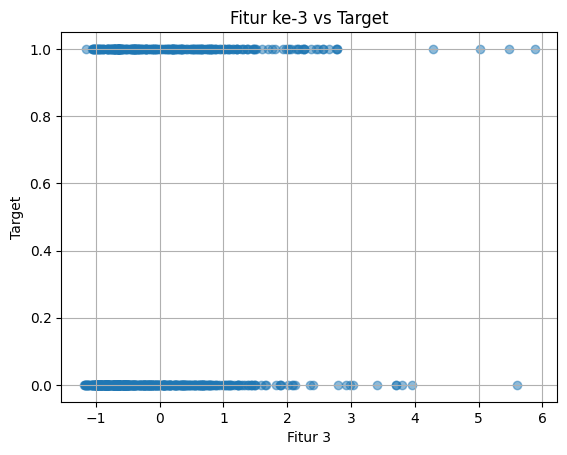

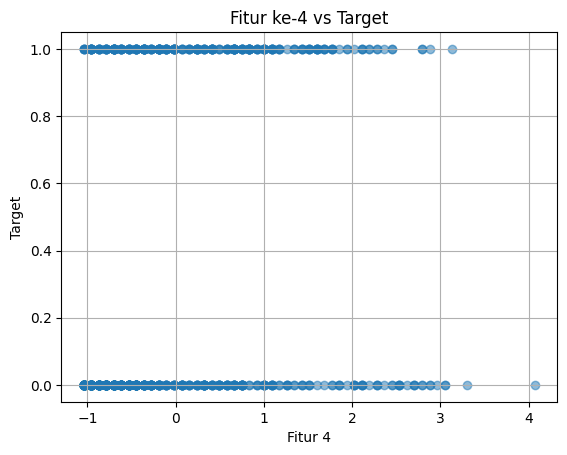

In [58]:
import matplotlib.pyplot as plt

for i in range(X.shape[1]):
    plt.scatter(X[:, i], y, alpha=0.5)
    plt.title(f"Fitur ke-{i+1} vs Target")
    plt.xlabel(f"Fitur {i+1}")
    plt.ylabel("Target")
    plt.grid(True)
    plt.show()

##### Lihat Distribusi Data

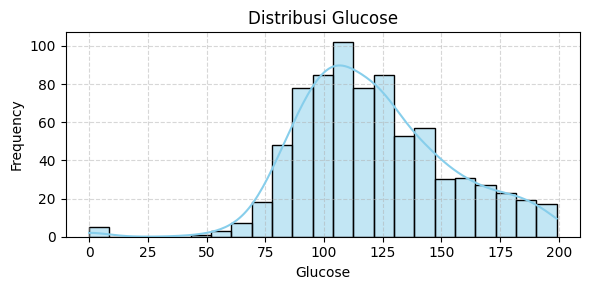

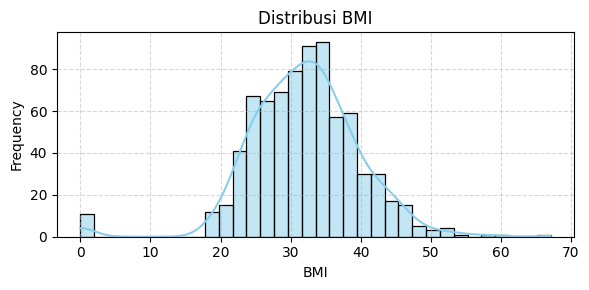

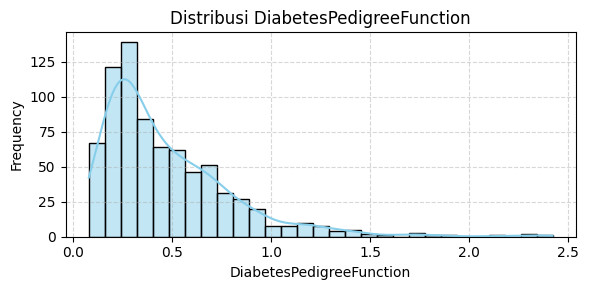

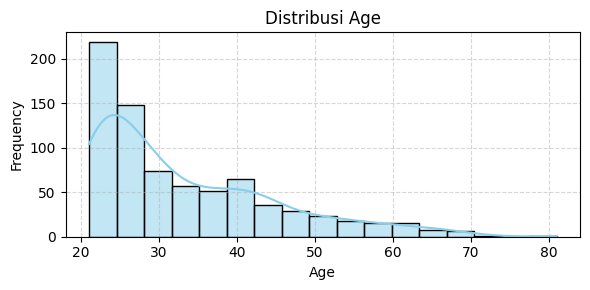

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Buat histogram dan KDE (curve) untuk setiap kolom numerik
for col in selected_features:  # Exclude 'Outcome'
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
class LinearRegression:
    def __init__(self): #Tempat untuk weight dan bias
        self.parameters = {}

    def forward_propagation(self, X): #Prediksi Linier
        W = self.parameters['W']  # Vector of weights
        b = self.parameters['b']
        return np.dot(X, W) + b  # Linear prediction

    def cost_function(self, predictions, y): #Mean Squared Error (MSE) antara prediksi dan nilai asli y
        return np.mean((y - predictions) ** 2)

    def backward_propagation(self, X, y, predictions): #Hitung turunan (gradien) untuk W dan b menggunakan rumus turunan MSE. Gradient Descent
        m = len(y)
        dW = (2/m) * np.dot(X.T, (predictions - y))  # Gradient wrt W
        db = (2/m) * np.sum(predictions - y)         # Gradient wrt b
        return {'dW': dW, 'db': db}

    def update_parameters(self, grads, learning_rate): #Update bobot dan bias
        self.parameters['W'] -= learning_rate * grads['dW']
        self.parameters['b'] -= learning_rate * grads['db']

    def train(self, X, y, learning_rate=0.01, iters=100): #Train model
        n_features = X.shape[1]
        self.parameters['W'] = np.random.randn(n_features)
        self.parameters['b'] = 0
        self.loss = []

        for i in range(iters):
            predictions = self.forward_propagation(X)
            cost = self.cost_function(predictions, y)
            grads = self.backward_propagation(X, y, predictions)
            self.update_parameters(grads, learning_rate)
            self.loss.append(cost)
            print(f"Iteration {i+1}, Loss = {cost:.4f}")

        return self.parameters, self.loss

In [63]:
model = LinearRegression()
params, losses = model.train(X_train, y_train, learning_rate=0.01, iters=100)

# Setelah model selesai dilatih
y_pred = model.forward_propagation(X_test)

# 1. Hitung MSE
mse = model.cost_function(y_pred, y_test)
print(f"\n📉 MSE (Mean Squared Error) on Test Set: {mse:.4f}")

# 2. Hitung Accuracy
# Konversi prediksi ke 0 dan 1 pakai threshold
y_pred_class = (y_pred >= 0.5).astype(int)

# Hitung accuracy
accuracy = np.mean(y_pred_class == y_test)
print(f"✅ Accuracy on Test Set: {accuracy:.4f}")


Iteration 1, Loss = 7.5235
Iteration 2, Loss = 7.2001
Iteration 3, Loss = 6.8921
Iteration 4, Loss = 6.5989
Iteration 5, Loss = 6.3196
Iteration 6, Loss = 6.0535
Iteration 7, Loss = 5.8001
Iteration 8, Loss = 5.5585
Iteration 9, Loss = 5.3284
Iteration 10, Loss = 5.1090
Iteration 11, Loss = 4.8999
Iteration 12, Loss = 4.7005
Iteration 13, Loss = 4.5103
Iteration 14, Loss = 4.3290
Iteration 15, Loss = 4.1560
Iteration 16, Loss = 3.9909
Iteration 17, Loss = 3.8334
Iteration 18, Loss = 3.6831
Iteration 19, Loss = 3.5396
Iteration 20, Loss = 3.4026
Iteration 21, Loss = 3.2718
Iteration 22, Loss = 3.1468
Iteration 23, Loss = 3.0274
Iteration 24, Loss = 2.9134
Iteration 25, Loss = 2.8044
Iteration 26, Loss = 2.7002
Iteration 27, Loss = 2.6007
Iteration 28, Loss = 2.5055
Iteration 29, Loss = 2.4144
Iteration 30, Loss = 2.3273
Iteration 31, Loss = 2.2440
Iteration 32, Loss = 2.1643
Iteration 33, Loss = 2.0880
Iteration 34, Loss = 2.0149
Iteration 35, Loss = 1.9450
Iteration 36, Loss = 1.8780
I

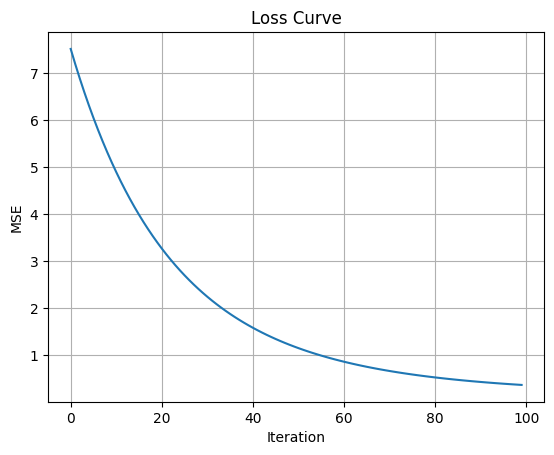

In [64]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

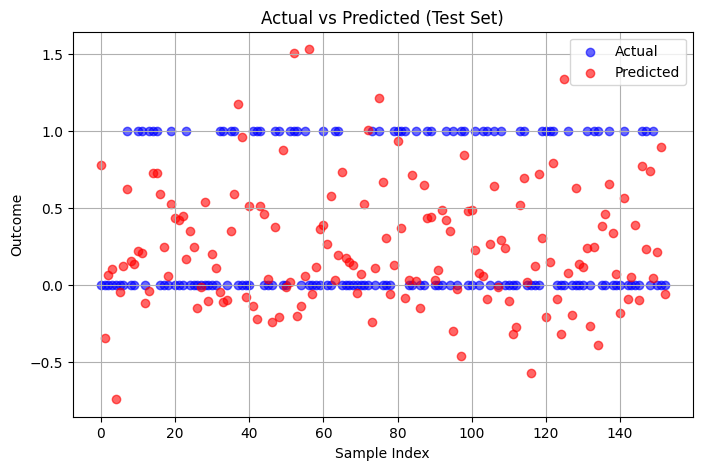

In [65]:
import matplotlib.pyplot as plt
# Visualisasi hasil prediksi vs aktual
plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.6)
plt.title('Actual vs Predicted (Test Set)')
plt.xlabel('Sample Index')
plt.ylabel('Outcome')
plt.legend()
plt.grid(True)
plt.show()

Klasifikasi tidak dapat menggunakan model regresi linier karena
1. Output Regresi Linier Tidak Terbatas dan bukan berupa probabilitas (Bisa < 0 atau > 1)
2. Linear regression untuk data continous yang outcomenya berupa numerik, bukan categorical sehingga tidak cocok untuk kasus ini
3. Tidak ada decision boundaries 

## Logistic Regression

##### Bisa untuk klasifikasi 

In [38]:
# Hyperparameter
learning_rate = 0.001 #Nilai kecil = belajar lambat tapi stabil
n_iter = 20000 #Karena learning rate kecil, kamu butuh iterasi banyak supaya bisa mencapai titik konvergen (loss menurun)
b = 0 #inisialisasi variabel bias
w = np.zeros(X.shape[1])

In [39]:
# Functions
predict = lambda x, w, b: np.dot(x, w) + b #Prediksi Linier
sigmoid = lambda z: 1 / (1 + np.exp(-z)) #Logit Z menjadi probabilitas antara 0 sampai 1
loss = lambda y, p: -(y*np.log(p) + (1-y)*np.log(1-p)).mean() #log-loss / binary cross-entropy; mengukur seberapa baik prediksi probabilitas p terhadap label asli y.
dldw = lambda x, y, p: np.dot((p - y), x) / x.shape[0] #gradien loss terhadap bobot (w)
dldb = lambda y, p: (p - y).mean() #gradien loss terhadap bias (b)
update = lambda param, grad, lr: param - lr * grad #update parameter dengan gradient descent dengan learning rate

In [40]:
# Training loop
losses = []
for i in range(n_iter):
    yhat = predict(X_train, w, b)
    sig = sigmoid(yhat)

    # Avoid log(0) error
    sig = np.clip(sig, 1e-10, 1 - 1e-10)

    logloss = loss(y_train, sig) #Simpan nilai loss ke list untuk nanti diplot sebagai learning curve
    losses.append(logloss)

    grad_w = dldw(X_train, y_train, sig) #Menghitung perubahan (gradien) yang dibutuhkan agar loss turu
    grad_b = dldb(y_train, sig)

    w = update(w, grad_w, learning_rate) #update parameter w dan b berdasarkan learning rate
    b = update(b, grad_b, learning_rate)

    if i % 100 == 0: #Print tiap 100 iterasi
        print(f"Iteration {i}, Loss = {logloss:.4f}")

Iteration 0, Loss = 0.6931
Iteration 100, Loss = 0.6827
Iteration 200, Loss = 0.6729
Iteration 300, Loss = 0.6637
Iteration 400, Loss = 0.6551
Iteration 500, Loss = 0.6470
Iteration 600, Loss = 0.6394
Iteration 700, Loss = 0.6323
Iteration 800, Loss = 0.6256
Iteration 900, Loss = 0.6192
Iteration 1000, Loss = 0.6133
Iteration 1100, Loss = 0.6077
Iteration 1200, Loss = 0.6024
Iteration 1300, Loss = 0.5974
Iteration 1400, Loss = 0.5927
Iteration 1500, Loss = 0.5882
Iteration 1600, Loss = 0.5840
Iteration 1700, Loss = 0.5800
Iteration 1800, Loss = 0.5762
Iteration 1900, Loss = 0.5726
Iteration 2000, Loss = 0.5692
Iteration 2100, Loss = 0.5660
Iteration 2200, Loss = 0.5629
Iteration 2300, Loss = 0.5600
Iteration 2400, Loss = 0.5573
Iteration 2500, Loss = 0.5546
Iteration 2600, Loss = 0.5521
Iteration 2700, Loss = 0.5497
Iteration 2800, Loss = 0.5474
Iteration 2900, Loss = 0.5452
Iteration 3000, Loss = 0.5431
Iteration 3100, Loss = 0.5412
Iteration 3200, Loss = 0.5393
Iteration 3300, Loss =

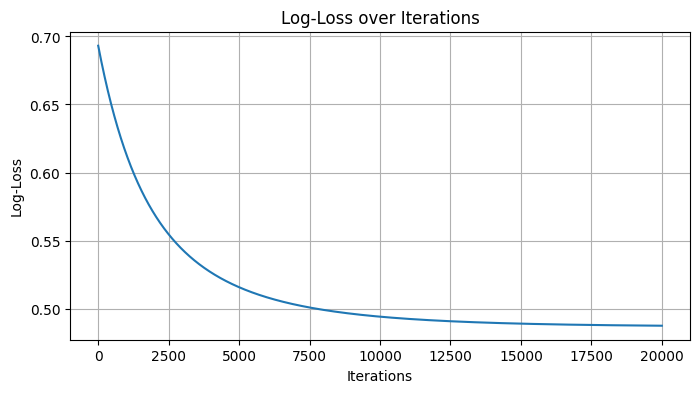

In [41]:
# Plot Loss Curve
plt.figure(figsize=(8,4))
plt.plot(losses)
plt.title("Log-Loss over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Log-Loss")
plt.grid(True)
plt.show()

In [42]:
# Prediksi test set
y_pred_proba = sigmoid(predict(X_test, w, b)) # predict lalu masuk ke fungsi sigmoid
y_pred_class = (y_pred_proba >= 0.5).astype(int) #Konversi probabilitas jadi kelas:Jika ≥ 0.5 → kelas 1, Jika < 0.5 → kelas 0
#.astype(int) supaya hasilnya berupa 0 dan 1

# Akurasi
acc = (y_pred_class == y_test).mean()
print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.7908


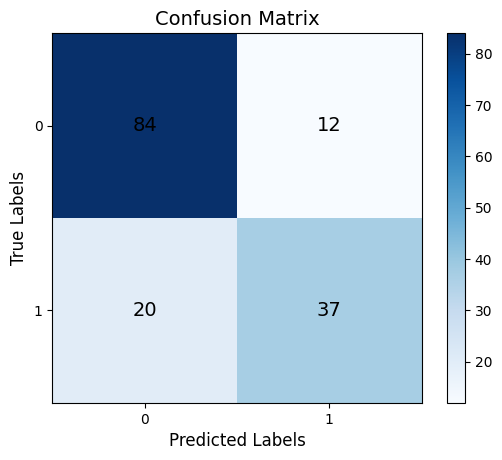

ROC AUC (Logistic Regression): 0.8433


In [43]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, labels=[0, 1]):
    # Buat 2x2 confusion matrix
    cm = np.zeros((2, 2), dtype=int)
    
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1

    # Plot
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap='Blues')

    # Tampilkan angka di dalam sel
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14)

    ax.set_xlabel('Predicted Labels', fontsize=12)
    ax.set_ylabel('True Labels', fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_title("Confusion Matrix", fontsize=14)
    plt.colorbar(im)
    plt.show()
# y_test dan y_pred_class harus sudah tersedia
plot_confusion_matrix(y_test, y_pred_class)

def roc_auc(y_true, y_pred_prob):
    thresholds = np.linspace(0, 1, 100)
    TPR = []
    FPR = []
    for t in thresholds:
        y_pred = (y_pred_prob >= t).astype(int)
        TP = np.sum((y_true == 1) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))
        tpr = TP / (TP + FN + 1e-10)
        fpr = FP / (FP + TN + 1e-10)
        TPR.append(tpr)
        FPR.append(fpr)
    
    auc = -1 * np.trapezoid(TPR, FPR)
    return auc, FPR, TPR

# ROC-AUC
auc_log, fpr_log, tpr_log = roc_auc(y_test, y_pred_proba)
print(f"ROC AUC (Logistic Regression): {auc_log:.4f}")


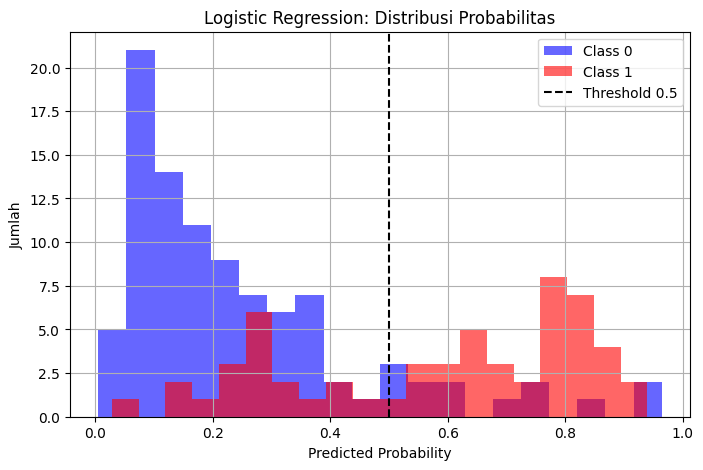

In [104]:
plt.figure(figsize=(8, 5))
plt.hist(y_pred_proba[y_test == 0], bins=20, alpha=0.6, label='Class 0', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=20, alpha=0.6, label='Class 1', color='red')
plt.axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
plt.title('Logistic Regression: Distribusi Probabilitas')
plt.xlabel('Predicted Probability')
plt.ylabel('Jumlah')
plt.legend()
plt.grid(True)
plt.show()


Idealnya: 

- Semua Class 0 berada jauh di kiri (misalnya < 0.3)
- Semua Class 1 berada jauh di kanan (misalnya > 0.7)

Ini akan membuat klasifikasi mudah dan akurat dengan threshold 0.5

1. Class 0 (biru) banyak berada di probabilitas rendah (0.0–0.4) → sesuai keinginan.
2. Class 1 (merah) cenderung berada di probabilitas tinggi (0.6–1.0) → sesuai keinginan.
3. Area ungu menunjukkan overlap: artinya ada probabilitas yang mirip untuk Class 0 dan Class 1 → kemungkinan terjadi kesalahan klasifikasi di sini.

##### Hasil dengan Logistic regression cukup baik karena menggunakan fungsi sigmoid sehingga tepat digunakan untuk klasifikasi karena dapat di dekatkan ke 0 atau 1 

## KNN

##### Jumlah data ≥ 500 dengan Target (Outcome) yang tidak terlalu imbang, jadi perlu lebih banyak tetangga untuk memperkuat keputusan.

In [25]:
def calculate_distance(x1, x2, method='euclidean', p=3):
    if method == 'euclidean':
        return np.sqrt(np.sum((x1 - x2) ** 2))
    elif method == 'manhattan':
        return np.sum(np.abs(x1 - x2))
    elif method == 'chebyshev':
        return np.max(np.abs(x1 - x2))
    elif method == 'minkowski':
        return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)
    elif method == 'cosine':
        dot = np.dot(x1, x2)
        norm_x1 = np.linalg.norm(x1)
        norm_x2 = np.linalg.norm(x2)
        return 1 - dot / (norm_x1 * norm_x2 + 1e-10)  # tambahkan epsilon biar gak divide by zero
    elif method == 'minkowski':
        return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)

    elif method == 'hamming':
        return np.mean(x1 != x2)
    else:
        raise ValueError(f"Unknown distance method: {method}")

In [26]:
k=20
def knn_predict(X_train, y_train, x_test, k=5, distance_method='euclidean'):
    distances = []

    for i in range(len(X_train)):
        dist = calculate_distance(X_train[i], x_test, method=distance_method)
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    k_neighbors = distances[:k]
    votes = [label for _, label in k_neighbors]
    prediction = max(set(votes), key=votes.count)
    return prediction

In [27]:
def evaluate_knn(X_train, y_train, X_test, y_test, k=k, distance_method='euclidean'):
    predictions = []

    for x in X_test:
        pred = knn_predict(X_train, y_train, x, k, distance_method=distance_method)
        predictions.append(pred)

    accuracy = np.mean(np.array(predictions) == y_test)
    return accuracy, predictions

In [28]:
# Jalankan evaluasi
acc, preds = evaluate_knn(X_train, y_train, X_test, y_test, k=k)
print(f"KNN Accuracy on Test Set (k=20): {acc:.4f}")

KNN Accuracy on Test Set (k=20): 0.8235


In [29]:
# pred_probs = proporsi tetangga yang class=1
pred_probs = []
for x in X_test:
    distances = []
    for i in range(len(X_train)):
        dist = calculate_distance(X_train[i], x, method='euclidean')
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    k_neighbors = distances[:k]
    votes = [label for _, label in k_neighbors]
    
    prob = np.mean(votes)  # probabilitas class=1
    pred_probs.append(prob)


In [31]:
from sklearn.metrics import roc_auc_score

roc_auc_knn = roc_auc_score(y_test, pred_probs)
print(f"KNN ROC AUC: {roc_auc_knn:.4f}")


KNN ROC AUC: 0.8512


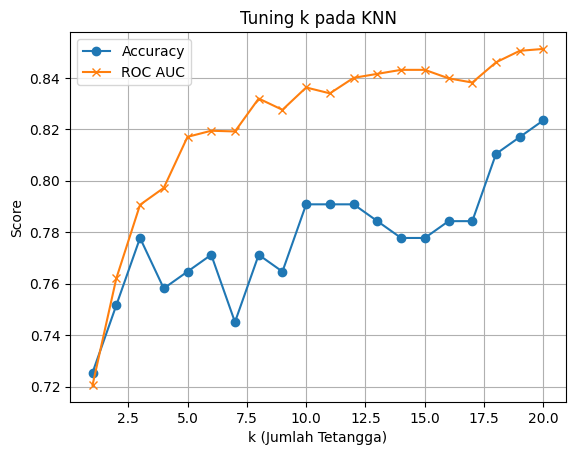

In [45]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

acc_list = []
roc_auc_list = []
k_range = range(1, 21)

for k in k_range:
    acc, pred = evaluate_knn(X_train, y_train, X_test, y_test, k=k)
    acc_list.append(acc)

    # Hitung ulang probabilitas class=1 untuk ROC AUC
    pred_probs = []
    for x in X_test:
        distances = []
        for i in range(len(X_train)):
            dist = calculate_distance(X_train[i], x, method='euclidean')  # bisa diganti
            distances.append((dist, y_train[i]))

        distances.sort(key=lambda x: x[0])
        k_neighbors = distances[:k]
        votes = [label for _, label in k_neighbors]
        prob = np.mean(votes)
        pred_probs.append(prob)

    roc_auc_knn = roc_auc_score(y_test, pred_probs)
    roc_auc_list.append(roc_auc_knn)

# Visualisasi
plt.plot(k_range, acc_list, marker='o', label='Accuracy')
plt.plot(k_range, roc_auc_list, marker='x', label='ROC AUC')
plt.xlabel('k (Jumlah Tetangga)')
plt.ylabel('Score')
plt.title('Tuning k pada KNN')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Coba pakai Manhattan
acc_manhattan, preds_manhattan = evaluate_knn(
    X_train, y_train, X_test, y_test, k=k,
    distance_method='manhattan'
)
print(f"KNN Accuracy (Manhattan): {acc_manhattan:.4f}")


KNN Accuracy (Manhattan): 0.7712


In [37]:
from sklearn.metrics import roc_auc_score

methods = ['euclidean', 'manhattan', 'chebyshev', 'cosine', 'minkowski', 'hamming']

for method in methods:
    acc, pred = evaluate_knn(X_train, y_train, X_test, y_test, k=k, distance_method=method)

    # Hitung probabilitas class 1 dari voting k tetangga
    pred_probs = []
    for x in X_test:
        distances = []
        for i in range(len(X_train)):
            dist = calculate_distance(X_train[i], x, method=method)
            distances.append((dist, y_train[i]))

        distances.sort(key=lambda x: x[0])
        k_neighbors = distances[:k]
        votes = [label for _, label in k_neighbors]
        prob = np.mean(votes)
        pred_probs.append(prob)

    auc = roc_auc_score(y_test, pred_probs)
    print(f"{method.title():<10} → Accuracy: {acc:.4f}, ROC AUC: {auc:.4f}")


Euclidean  → Accuracy: 0.8235, ROC AUC: 0.8512
Manhattan  → Accuracy: 0.7712, ROC AUC: 0.8588
Chebyshev  → Accuracy: 0.7974, ROC AUC: 0.8370
Cosine     → Accuracy: 0.7843, ROC AUC: 0.8341
Minkowski  → Accuracy: 0.8170, ROC AUC: 0.8480
Hamming    → Accuracy: 0.6536, ROC AUC: 0.7077


- Euclidean → Bekerja baik saat semua fitur sudah dinormalisasi, mempertimbangkan kuadrat selisih → lebih sensitif terhadap perbedaan jarak besar vs kecil
- Minkowski → Memberi bobot lebih pada perbedaan besar, tapi tidak sekuat Euclidean
- Manhattan → Menghitung total selisih absolut dari tiap fitur sehingga kurang presisi untuk data ternormalisasi
- Chebyshev → Perbedaan terbesar saja dari semua fitur dan cocok untuk data frekuensi, vektor teks, atau sparse data
- Hamming → HANYA cocok untuk data kategorikal/biner

📊 Evaluation Metrics for KNN
✅ Accuracy : 0.8235
🎯 Precision: 0.7778
📈 Recall   : 0.7368
🎯 F1 Score : 0.7568
🏁 ROC AUC  : 0.8512

Confusion Matrix:
[[84 12]
 [15 42]]


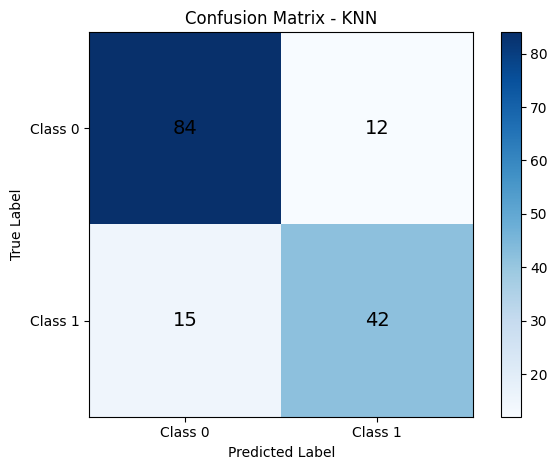

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

def evaluate_and_plot(y_true, y_pred, y_prob=None, model_name="Model"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Confusion Matrix
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    cm = np.array([[TN, FP],
                   [FN, TP]])

    # Metrics
    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    
    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except:
        roc_auc = None

    # Print metrics
    print(f"📊 Evaluation Metrics for {model_name}")
    print(f"✅ Accuracy : {accuracy:.4f}")
    print(f"🎯 Precision: {precision:.4f}")
    print(f"📈 Recall   : {recall:.4f}")
    print(f"🎯 F1 Score : {f1:.4f}")
    
    if roc_auc is not None:
        print(f"🏁 ROC AUC  : {roc_auc:.4f}")

    print(f"\nConfusion Matrix:\n{cm}")
    
    # Plot confusion matrix
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=14)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Class 0", "Class 1"])
    ax.set_yticklabels(["Class 0", "Class 1"])
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

evaluate_and_plot(y_test, preds,y_prob=pred_probs, model_name="KNN")


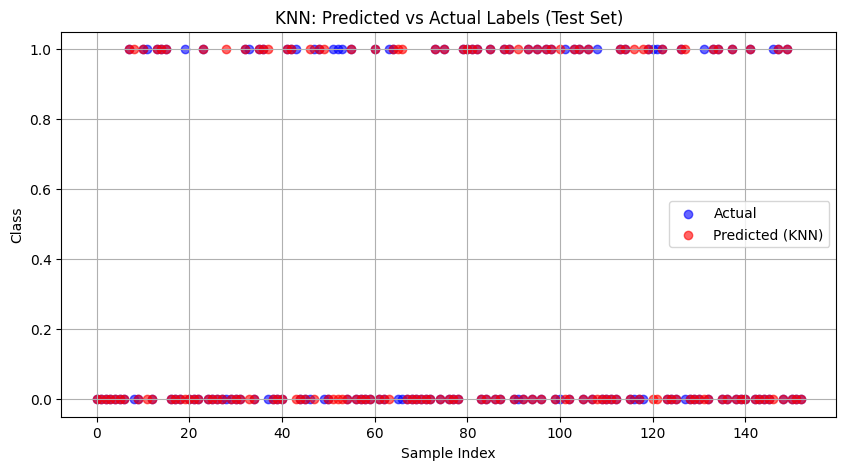

In [119]:
import matplotlib.pyplot as plt

# Visualisasi: Prediksi vs Aktual
plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_test)), y_test, label="Actual", color='blue', alpha=0.6)
plt.scatter(range(len(preds)), preds, label="Predicted (KNN)", color='red', alpha=0.6)
plt.title("KNN: Predicted vs Actual Labels (Test Set)")
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.legend()
plt.grid(True)
plt.show()


### Cross Validation

✅ Konsep: K-Fold Cross Validation
- Dataset dibagi jadi k bagian (folds)
- Model dilatih di k-1 bagian dan diuji di 1 bagian
- Ulangi proses ini sebanyak k kali, rotasi test fold-nya
- Ambil rata-rata akurasi / metrik lain dari semua fold



In [47]:
def k_fold_split(X, y, k=k, seed=42):
    np.random.seed(seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    fold_size = len(X) // k
    folds = []

    for i in range(k):
        start = i * fold_size
        end = start + fold_size if i != k - 1 else len(X)
        val_idx = indices[start:end]
        train_idx = np.concatenate((indices[:start], indices[end:]))
        folds.append((train_idx, val_idx))
    
    return folds


In [48]:
from sklearn.metrics import roc_auc_score

def cross_validate_knn(X, y, k_neighbors=k, cv=5, distance_method='euclidean'):
    folds = k_fold_split(X, y, k=cv)
    acc_scores = []
    auc_scores = []

    for train_idx, val_idx in folds:
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Prediksi probabilitas: proporsi tetangga yang positif
        y_proba = []
        y_class = []
        for x in X_val:
            distances = []
            for i in range(len(X_train)):
                dist = calculate_distance(X_train[i], x, method=distance_method)
                distances.append((dist, y_train[i]))

            distances.sort(key=lambda x: x[0])
            k_neighbors_list = distances[:k_neighbors]
            votes = [label for _, label in k_neighbors_list]

            # Probabilitas: rasio yang bernilai 1
            prob = np.mean(votes)
            y_proba.append(prob)

            # Kelas: threshold default 0.5
            y_class.append(1 if prob >= 0.5 else 0)

        acc = (np.array(y_class) == y_val).mean()
        auc = roc_auc_score(y_val, y_proba)

        acc_scores.append(acc)
        auc_scores.append(auc)

    avg_acc = np.mean(acc_scores)
    avg_auc = np.mean(auc_scores)

    return avg_acc, avg_auc


In [49]:
# Misal kamu mau cross-validate KNN k=20
avg_acc, avg_auc = cross_validate_knn(X, y, k_neighbors=20, cv=5)

print(f"📊 Hasil 5-Fold CV KNN (k=20):")
print(f"Average Accuracy: {avg_acc:.4f}")
print(f"Average ROC-AUC : {avg_auc:.4f}")


📊 Hasil 5-Fold CV KNN (k=20):
Average Accuracy: 0.7718
Average ROC-AUC : 0.8276


In [50]:
for k_val in [3, 5, 10, 20]:
    acc, mse = cross_validate_knn(X, y, k_neighbors=k_val)
    print(f"k={k_val:<2} → Acc: {acc:.4f}, MSE: {mse:.4f}")


k=3  → Acc: 0.7353, MSE: 0.7417
k=5  → Acc: 0.7522, MSE: 0.7840
k=10 → Acc: 0.7652, MSE: 0.8181
k=20 → Acc: 0.7718, MSE: 0.8276


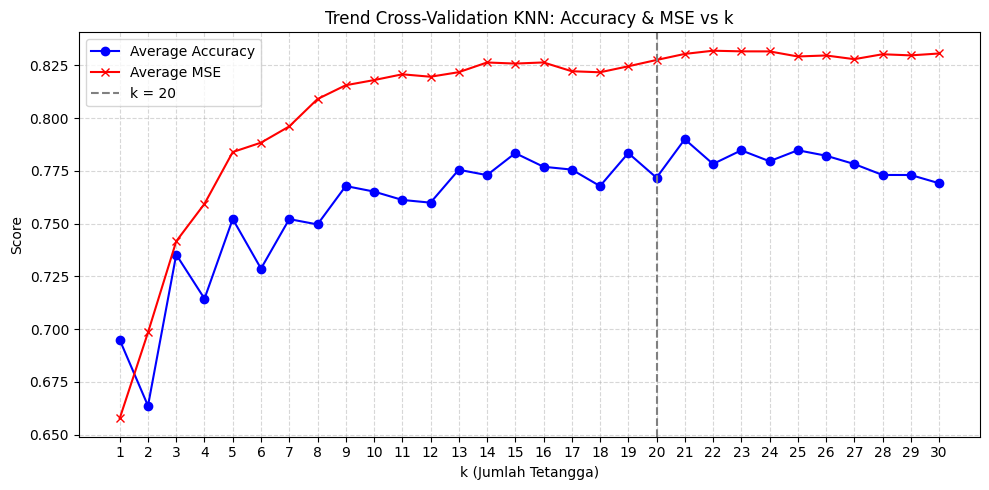

In [24]:
k_range = range(1, 31)  # Uji dari k=1 sampai k=30
acc_scores = []
mse_scores = []

for k_val in k_range:
    avg_acc, avg_mse = cross_validate_knn(X, y, k_neighbors=k_val, cv=5)
    acc_scores.append(avg_acc)
    mse_scores.append(avg_mse)

# Visualisasi hasil
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(k_range, acc_scores, marker='o', label='Average Accuracy', color='blue')
plt.plot(k_range, mse_scores, marker='x', label='Average MSE', color='red')
plt.axvline(x=20, linestyle='--', color='gray', label='k = 20')
plt.title('Trend Cross-Validation KNN: Accuracy & MSE vs k')
plt.xlabel('k (Jumlah Tetangga)')
plt.ylabel('Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🔵 Kurva biru (accuracy): naik → optimal → turun = pertanda overfit atau underfit.

🔴 Kurva merah (ROC AUC): Semakin tinggi semakin baik

🚧 Jika k terlalu kecil → model terlalu peka → overfitting.

🧱 Jika k terlalu besar → model jadi kurang tajam → underfitting.